In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/albertobircoci/support-ticket-priority-dataset-50k/Support_tickets.csv


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/albertobircoci/support-ticket-priority-dataset-50k/Support_tickets.csv')

df.head()

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 33)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               50000 non-null  int64  
 1   day_of_week             50000 non-null  object 
 2   day_of_week_num         50000 non-null  int64  
 3   company_id              50000 non-null  int64  
 4   company_size            50000 non-null  object 
 5   company_size_cat        50000 non-null  int64  
 6   industry                50000 non-null  object 
 7   industry_cat            50000 non-null  int64  
 8   customer_tier           50000 non-null  object 
 9   customer_tier_cat       50000 non-null  int64  
 10  org_users               50000 non-null  int64  
 11  region                  50000 non-null  object 
 12  region_cat              50000 non-null  int64  
 13  past_30d_tickets        50000 non-null  int64  
 14  past_90d_incidents      50000 non-null

In [6]:
df.columns.tolist()

['ticket_id',
 'day_of_week',
 'day_of_week_num',
 'company_id',
 'company_size',
 'company_size_cat',
 'industry',
 'industry_cat',
 'customer_tier',
 'customer_tier_cat',
 'org_users',
 'region',
 'region_cat',
 'past_30d_tickets',
 'past_90d_incidents',
 'product_area',
 'product_area_cat',
 'booking_channel',
 'booking_channel_cat',
 'reported_by_role',
 'reported_by_role_cat',
 'customers_affected',
 'error_rate_pct',
 'downtime_min',
 'payment_impact_flag',
 'security_incident_flag',
 'data_loss_flag',
 'has_runbook',
 'customer_sentiment',
 'customer_sentiment_cat',
 'description_length',
 'priority',
 'priority_cat']

In [7]:
df.head()

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1


In [8]:
print(df.isnull().sum())

ticket_id                   0
day_of_week                 0
day_of_week_num             0
company_id                  0
company_size                0
company_size_cat            0
industry                    0
industry_cat                0
customer_tier               0
customer_tier_cat           0
org_users                   0
region                      0
region_cat                  0
past_30d_tickets            0
past_90d_incidents          0
product_area                0
product_area_cat            0
booking_channel             0
booking_channel_cat         0
reported_by_role            0
reported_by_role_cat        0
customers_affected          0
error_rate_pct              0
downtime_min                0
payment_impact_flag         0
security_incident_flag      0
data_loss_flag              0
has_runbook                 0
customer_sentiment        906
customer_sentiment_cat      0
description_length          0
priority                    0
priority_cat                0
dtype: int

In [9]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 906


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
print(df.columns.tolist())

['ticket_id', 'day_of_week', 'day_of_week_num', 'company_id', 'company_size', 'company_size_cat', 'industry', 'industry_cat', 'customer_tier', 'customer_tier_cat', 'org_users', 'region', 'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area', 'product_area_cat', 'booking_channel', 'booking_channel_cat', 'reported_by_role', 'reported_by_role_cat', 'customers_affected', 'error_rate_pct', 'downtime_min', 'payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook', 'customer_sentiment', 'customer_sentiment_cat', 'description_length', 'priority', 'priority_cat']


In [13]:
print(df['priority'].value_counts())

priority
low       25000
medium    17500
high       7500
Name: count, dtype: int64


In [17]:
print(df.columns)

Index(['ticket_id', 'day_of_week', 'day_of_week_num', 'company_id',
       'company_size', 'company_size_cat', 'industry', 'industry_cat',
       'customer_tier', 'customer_tier_cat', 'org_users', 'region',
       'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area',
       'product_area_cat', 'booking_channel', 'booking_channel_cat',
       'reported_by_role', 'reported_by_role_cat', 'customers_affected',
       'error_rate_pct', 'downtime_min', 'payment_impact_flag',
       'security_incident_flag', 'data_loss_flag', 'has_runbook',
       'customer_sentiment', 'customer_sentiment_cat', 'description_length',
       'priority', 'priority_cat'],
      dtype='object')


In [18]:
'priority' in df.columns

True

In [19]:
'priority_cat' in df.columns

True

In [20]:
df[['priority', 'priority_cat']].head()

,priority,priority_cat
0,low,1
1,low,1
2,low,1
3,medium,2
4,low,1


In [21]:
y = df['priority']

X = df.drop(columns=['priority', 'priority_cat'], errors='ignore')

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:")
print(y.value_counts())

X shape: (50000, 31)
y shape: (50000,)
Target classes:
priority
low       25000
medium    17500
high       7500
Name: count, dtype: int64


In [22]:
X = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

print("Encoding completed")
print("X shape after encoding:", X.shape)
print("Target labels:", le.classes_)

Encoding completed
X shape after encoding: (50000, 54)
Target labels: ['high' 'low' 'medium']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 54)
Test shape: (10000, 54)


In [24]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8561
Precision: 0.8557535743036189
Recall: 0.8561
F1 Score: 0.8553042225943199
              precision    recall  f1-score   support

        high       0.85      0.74      0.79      1500
         low       0.90      0.93      0.92      5000
      medium       0.79      0.80      0.80      3500

    accuracy                           0.86     10000
   macro avg       0.85      0.82      0.83     10000
weighted avg       0.86      0.86      0.86     10000



In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8561
Precision: 0.8557535743036189
Recall: 0.8561
F1 Score: 0.8553042225943199
              precision    recall  f1-score   support

        high       0.85      0.74      0.79      1500
         low       0.90      0.93      0.92      5000
      medium       0.79      0.80      0.80      3500

    accuracy                           0.86     10000
   macro avg       0.85      0.82      0.83     10000
weighted avg       0.86      0.86      0.86     10000



In [27]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Accuracy : 0.9159
Precision: 0.9161826690744108
Recall   : 0.9159
F1 Score : 0.915681717172139

Classification Report
              precision    recall  f1-score   support

        high       0.92      0.84      0.88      1500
         low       0.95      0.96      0.95      5000
      medium       0.87      0.89      0.88      3500

    accuracy                           0.92     10000
   macro avg       0.91      0.89      0.90     10000
weighted avg       0.92      0.92      0.92     10000



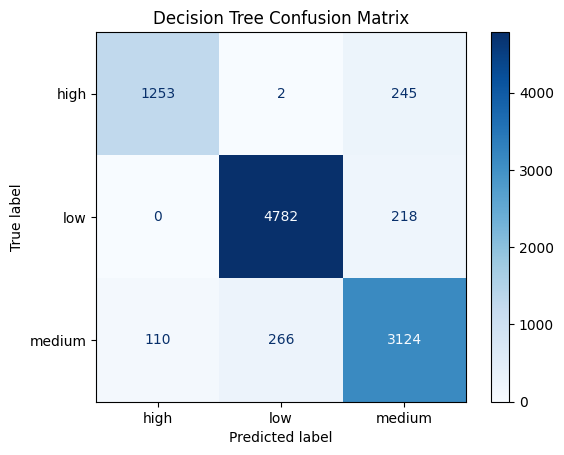

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy : 0.9122
Precision: 0.9135194894327243
Recall   : 0.9122
F1 Score : 0.9116980632599492
              precision    recall  f1-score   support

        high       0.95      0.80      0.87      1500
         low       0.94      0.96      0.95      5000
      medium       0.86      0.89      0.88      3500

    accuracy                           0.91     10000
   macro avg       0.92      0.88      0.90     10000
weighted avg       0.91      0.91      0.91     10000



In [32]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
15,downtime_min,0.208493
13,customers_affected,0.192260
14,error_rate_pct,0.090533
21,description_length,0.052045
6,org_users,0.049871
3,company_size_cat,0.032376
0,ticket_id,0.031696
29,company_size_Small,0.027875
10,product_area_cat,0.027187
8,past_30d_tickets,0.024483


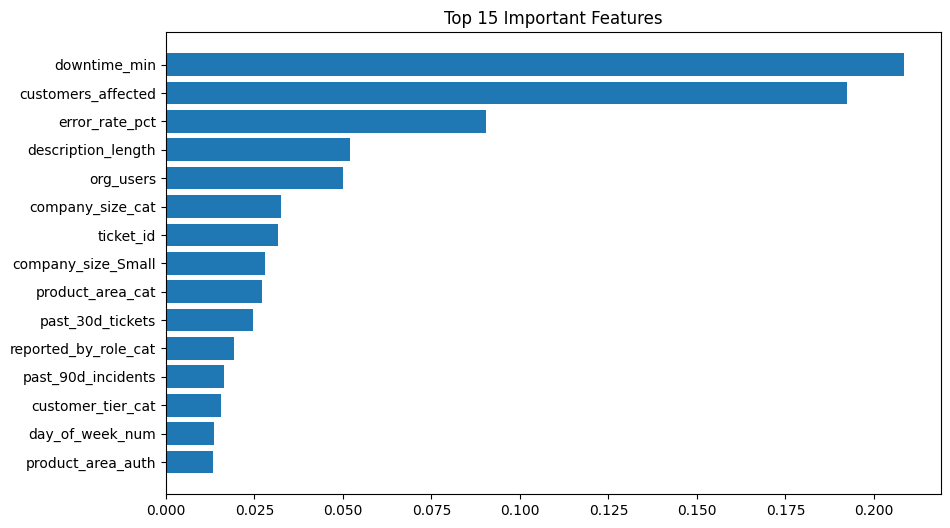

In [33]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [34]:
import xgboost

print(xgboost.__version__)

3.2.0


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [37]:
y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy : 0.9712
Precision: 0.971356669000035
Recall   : 0.9712
F1 Score : 0.9711728695530779
              precision    recall  f1-score   support

        high       0.98      0.93      0.95      1500
         low       0.98      0.99      0.98      5000
      medium       0.95      0.97      0.96      3500

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [38]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb
    ],
    'Precision': [
        precision,
        precision_dt,
        precision_rf,
        precision_xgb
    ],
    'Recall': [
        recall,
        recall_dt,
        recall_rf,
        recall_xgb
    ],
    'F1 Score': [
        f1,
        f1_dt,
        f1_rf,
        f1_xgb
    ]
})

comparison

NameError: name 'accuracy' is not defined

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = log_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.8561
Precision: 0.8557535743036189
Recall: 0.8561
F1: 0.8553042225943199


In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                         ticket_id  day_of<...>[50000 rows x 54 columns]
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   ndarray      

In [42]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_dt, precision_rf, precision_xgb],
    'Recall': [recall, recall_dt, recall_rf, recall_xgb],
    'F1 Score': [f1, f1_dt, f1_rf, f1_xgb]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8561,0.855754,0.8561,0.855304
1,Decision Tree,0.9159,0.916183,0.9159,0.915682
2,Random Forest,0.9122,0.913519,0.9122,0.911698
3,XGBoost,0.9712,0.971357,0.9712,0.971173


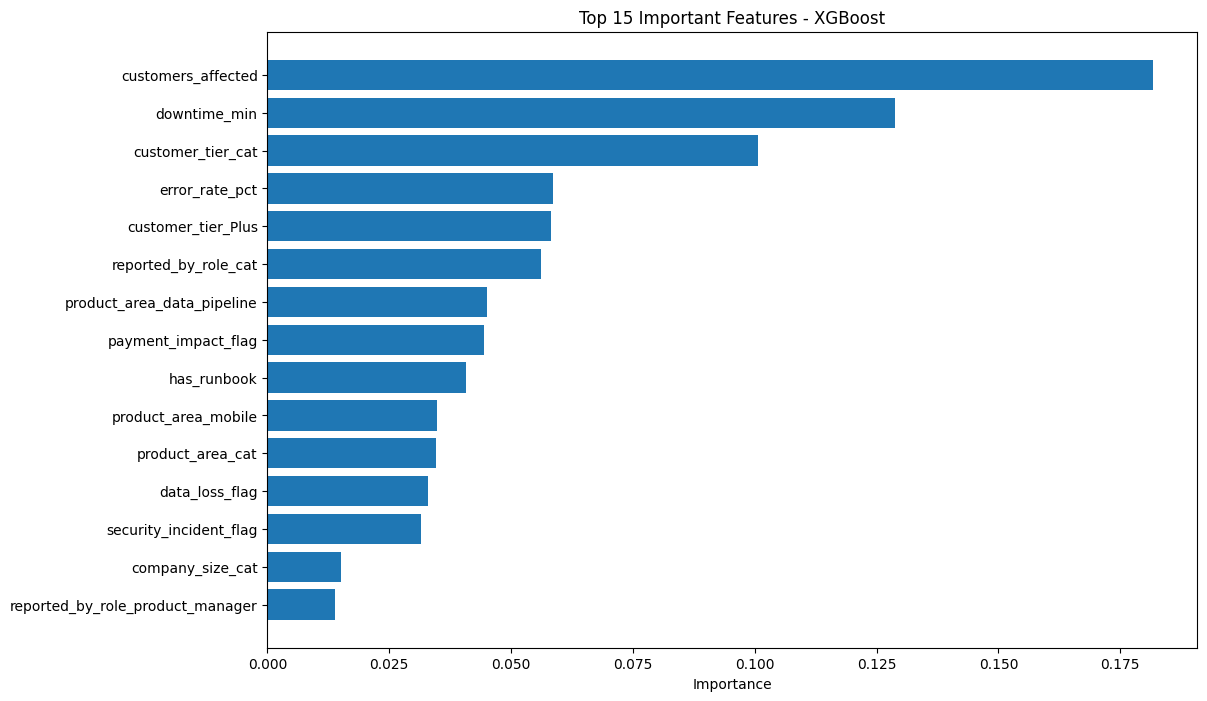

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Important Features - XGBoost")

plt.show()

In [44]:
plt.savefig(
    "XGBoost_FeatureImportance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

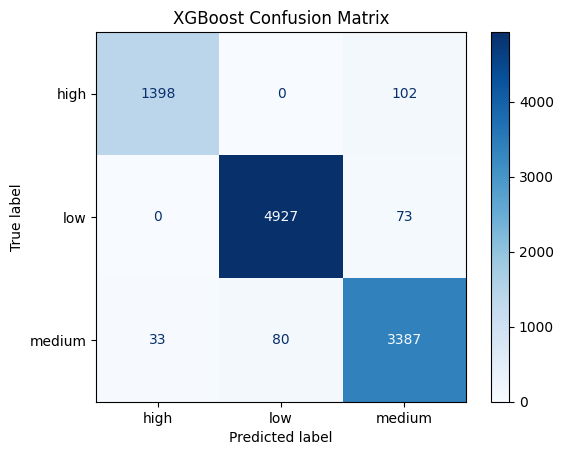

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [46]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb,
    multi_class="ovr"
)

print("ROC-AUC:", roc_auc)

NameError: name 'y_prob_xgb' is not defined

In [47]:
# Predicted probabilities for each class
y_prob_xgb = xgb_model.predict_proba(X_test)

print(y_prob_xgb.shape)

(10000, 3)


In [48]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC:", round(roc_auc, 4))

Weighted ROC-AUC: 0.9981


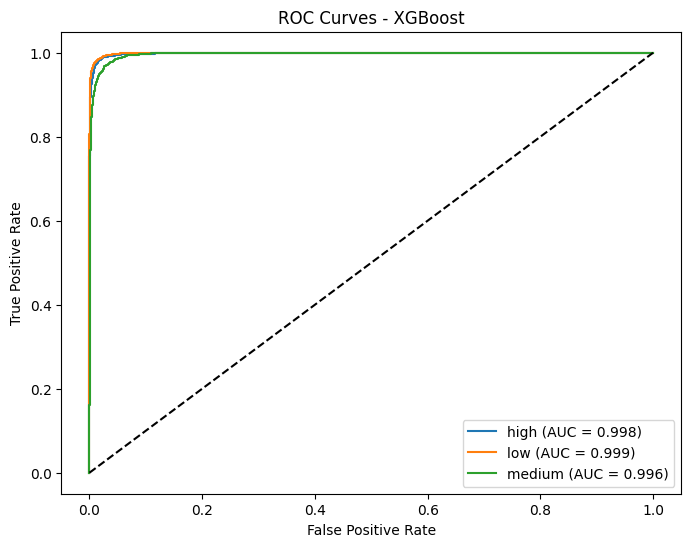

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Number of classes
n_classes = 3

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - XGBoost")
plt.legend()

plt.show()

In [50]:
plt.savefig(
    "ROC_Curve_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [51]:
comparison.to_csv("Model_Comparison.csv", index=False)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8561,0.855754,0.8561,0.855304
1,Decision Tree,0.9159,0.916183,0.9159,0.915682
2,Random Forest,0.9122,0.913519,0.9122,0.911698
3,XGBoost,0.9712,0.971357,0.9712,0.971173


In [52]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)

print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Accuracy : 0.8365
Precision: 0.8335580112799751
Recall   : 0.8365
F1 Score : 0.8330515587509312
              precision    recall  f1-score   support

        high       0.82      0.72      0.77      1500
         low       0.87      0.95      0.91      5000
      medium       0.79      0.72      0.76      3500

    accuracy                           0.84     10000
   macro avg       0.83      0.80      0.81     10000
weighted avg       0.83      0.84      0.83     10000



In [54]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],
    'Accuracy': [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb,
        accuracy_svm
    ],
    'Precision': [
        precision,
        precision_dt,
        precision_rf,
        precision_xgb,
        precision_svm
    ],
    'Recall': [
        recall,
        recall_dt,
        recall_rf,
        recall_xgb,
        recall_svm
    ],
    'F1 Score': [
        f1,
        f1_dt,
        f1_rf,
        f1_xgb,
        f1_svm
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8561,0.855754,0.8561,0.855304
1,Decision Tree,0.9159,0.916183,0.9159,0.915682
2,Random Forest,0.9122,0.913519,0.9122,0.911698
3,XGBoost,0.9712,0.971357,0.9712,0.971173
4,SVM,0.8365,0.833558,0.8365,0.833052


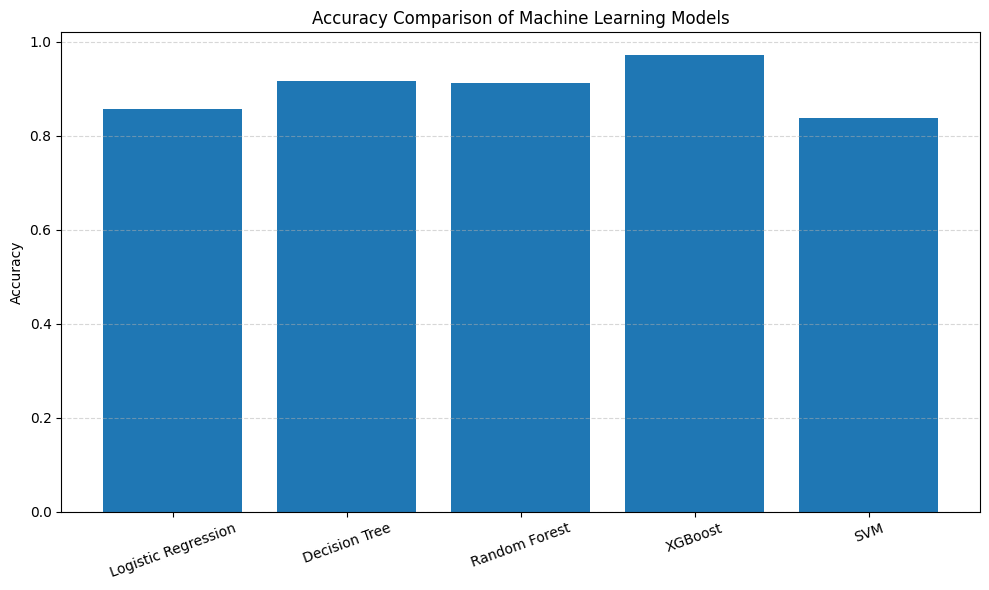

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("Model_Comparison.png", dpi=300)

plt.show()

In [62]:
comparison.to_csv("Model_Comparison.csv", index=False)

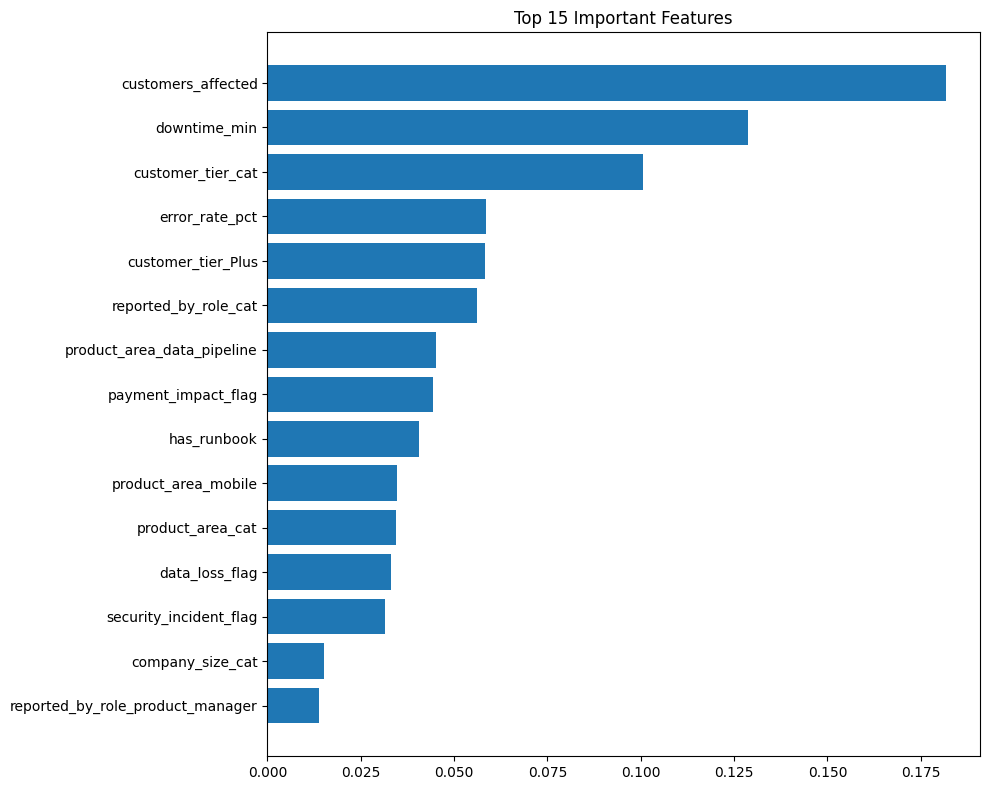

In [60]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig("Feature_Importance.png", dpi=300)

plt.show()

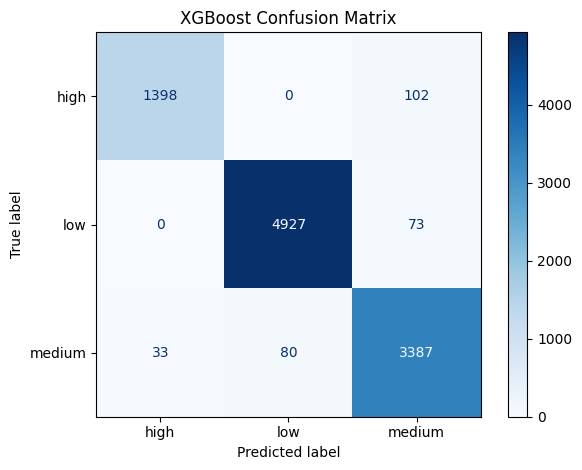

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.tight_layout()

plt.savefig("Confusion_Matrix.png", dpi=300)

plt.show()

In [66]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8561,0.855754,0.8561,0.855304
1,Decision Tree,0.9159,0.916183,0.9159,0.915682
2,Random Forest,0.9122,0.913519,0.9122,0.911698
3,XGBoost,0.9712,0.971357,0.9712,0.971173
4,SVM,0.8365,0.833558,0.8365,0.833052


In [69]:
comparison.to_csv("/kaggle/working/Model_Comparison.csv", index=False)
print("Saved successfully!")

Saved successfully!
